In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [21]:
# Load the dataset (assuming it's stored in a file)
data = pd.read_csv("heart.csv")

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [22]:
# Check dataset
print(data.shape)
print()
print(data.info())
print()
print(data.isnull().sum())

(1025, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dt

In [23]:
# Separate Features and Labels

X = data.iloc[:, :-1].values

y = data.iloc[:, -1].values

print("X Shape:", X.shape)

print("y Shape:", y.shape)

X Shape: (1025, 13)
y Shape: (1025,)


In [24]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(820, 13)
(205, 13)


In [25]:
# Normalize the feature data

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print(X_train[:5])

[[-5.85840222e-01  6.54653671e-01  1.00827500e+00 -7.79453566e-01
  -1.93503098e+00 -4.14039336e-01 -9.83741901e-01 -1.01909426e+00
  -7.25948939e-01 -2.10661213e-01  1.00526437e+00  2.17169136e+00
  -5.45193165e-01]
 [ 1.05147737e+00 -1.52752523e+00 -9.16720340e-01  2.74173173e+00
   1.61063407e+00 -4.14039336e-01  9.09845796e-01  2.02882145e-01
   1.37750735e+00 -9.12152360e-01  1.00526437e+00 -7.25467395e-01
  -5.45193165e-01]
 [-4.00676907e-02 -1.52752523e+00  1.00827500e+00 -1.34738668e+00
   4.42176271e-01 -4.14039336e-01 -9.83741901e-01  7.70228333e-01
  -7.25948939e-01 -9.12152360e-01  1.00526437e+00 -7.25467395e-01
  -5.45193165e-01]
 [ 5.05704840e-01  6.54653671e-01 -9.16720340e-01  1.86032724e-01
  -2.22635925e-01 -4.14039336e-01  9.09845796e-01  5.08376246e-01
  -7.25948939e-01 -4.73720393e-01 -6.40078509e-01 -7.25467395e-01
   1.11057867e+00]
 [-3.67531209e-01  6.54653671e-01  1.00827500e+00 -3.81900388e-01
  -1.03185928e-03  2.41522946e+00 -9.83741901e-01  7.26586318e-01


In [26]:
# Create and train the MLP model

mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    max_iter=6000,
    random_state=42
)

mlp.fit(X_train, y_train)

print("Training Completed")

Training Completed


In [27]:
# Make predictions on the testing set

y_pred = mlp.predict(X_test)

print(y_pred)

[1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0
 1 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 0 1 0 0 0 1
 1 1 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0
 1 1 0 1 1 0 1 1 0 1 1 0 0 1 0 1 1 0 1 1 0 1 1 0 1 0 1 1 0 1 1 1 1 1 1 0 1
 0 0 0 0 1 1 0 0 0 1 0 0 1 1 0 0 1 1 0 0 0 1 0 1 1 0 1 1 1 0 0 1 1 0 1 0 1
 1 1 0 1 1 1 0 0 0 0 1 1 0 1 1 1 1 1 0 0]


In [28]:
# Evaluate the model

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy =", accuracy * 100, "%")

Accuracy = 95.1219512195122 %


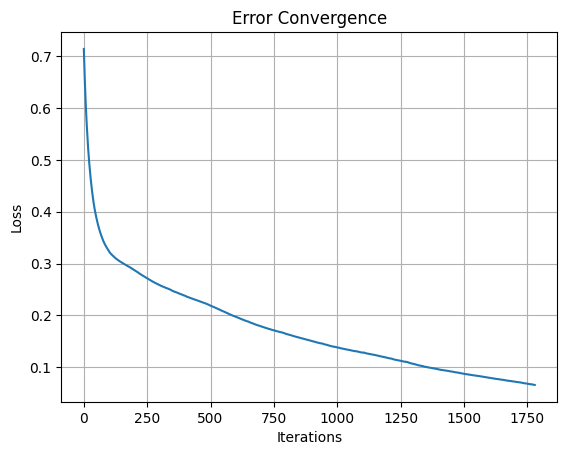

In [29]:
# Plot the error convergence

plt.plot(mlp.loss_curve_)

plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.title("Error Convergence")

plt.grid(True)

plt.show()